In [ ]:
# repo-root bootstrap: notebooks live in notebooks/, code lives one level up
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root / "spphot_eval.py").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))


# Spectrophotometric Distance Estimation — End-to-End Walkthrough

This notebook shows **every step** of the distance-estimation pipeline in this repo,
which reproduces and scores **Hogg, Eilers & Rix (2018)** ("spectrophotometric
parallaxes" for APOGEE red giants).

The pipeline, start to finish:

| step | what happens | where it lives |
|---|---|---|
| 1 | load the parent catalog (44,784 red giants) | `hogg2018.fits` |
| 2 | assemble features: 8-band photometry + APOGEE spectra | `assemble_features.py` (runs on Gadi) |
| 3 | fit the linear model $\ln\varpi^{(\mathrm{sp})} = \theta\cdot x$ in **parallax space** | demonstrated below on a toy problem |
| 4 | A/B cross-validation (never predict a star with a model that saw it) | `sample` column |
| 5 | predicted spectrophotometric parallaxes + uncertainties | `spec_parallax(_err)` columns |
| 6 | invert parallax → distance | this notebook |
| 7 | evaluate: robust scatter, bias, $\chi^2$ on the high-S/N probe | `spphot_eval.py` |
| 8 | diagnostic figures (Paper I Fig. 2, residual histogram) | `spphot_plots.py` |
| 9 | score your own model on identical footing | template at the end |

The published Zenodo catalog already contains the model's outputs, so steps 1, 4–8
run on the real data here. Step 2 needs the spectra (built on Gadi), and step 3 is
demonstrated with a fully working toy version of the exact same math.

## Step 1 — The data, and why we need this at all

The parent sample is APOGEE red-giant stars crossmatched to Gaia DR2. These are
**luminous, distant** stars — exactly the ones where Gaia's geometric parallax is
weakest. The whole point of the method: a star's spectrum + photometry predict its
luminosity (and hence parallax) far more precisely than Gaia can measure it
geometrically at these distances.

Two facts below motivate everything that follows:
- a noticeable fraction of Gaia parallaxes are **negative** (pure noise scatter), and
- most stars have **low Gaia parallax S/N**.

If you cut those stars away you bias the sample toward nearby stars; the method
instead *keeps them all* by fitting in parallax space (step 3).

In [11]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from astropy.io import fits

import spphot_eval as E
import spphot_plots as P   # note: this import switches matplotlib to Agg...
%matplotlib inline
# ...so the magic above switches it back for inline figures.

cat = E.load_catalog("hogg2018.fits")
N = len(cat["plx_a"])
print(f"parent sample          : {N} stars")
print(f"training set           : {cat['train'].sum()}")
print(f"fold A / fold B        : {(cat['sample']=='A').sum()} / {(cat['sample']=='B').sum()}")
print(f"negative Gaia parallax : {100*(cat['plx_a']<0).mean():.1f}%  (kept! never cut)")

parent sample          : 44784 stars
training set           : 28226
fold A / fold B        : 22349 / 22435
negative Gaia parallax : 4.9%  (kept! never cut)


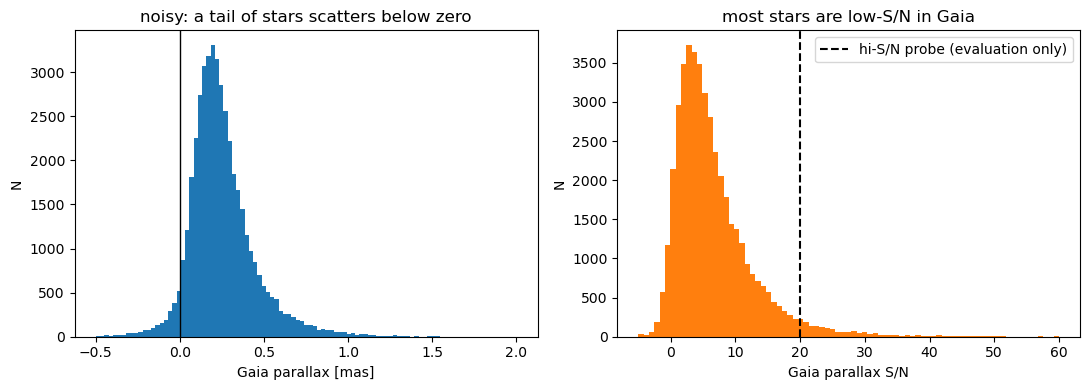

In [2]:
snr_a = cat["plx_a"] / cat["err_a"]
snr_a = np.where(np.isfinite(snr_a), snr_a, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(cat["plx_a"], bins=np.linspace(-0.5, 2.0, 100), color="C0")
ax[0].axvline(0, color="k", lw=1)
ax[0].set(xlabel="Gaia parallax [mas]", ylabel="N",
          title="noisy: a tail of stars scatters below zero")

ax[1].hist(np.clip(snr_a[np.isfinite(snr_a)], -5, 60), bins=np.linspace(-5, 60, 80), color="C1")
ax[1].axvline(20, color="k", ls="--", label="hi-S/N probe (evaluation only)")
ax[1].set(xlabel="Gaia parallax S/N", ylabel="N",
          title="most stars are low-S/N in Gaia")
ax[1].legend()
plt.tight_layout()

## Step 2 — Assemble the features

Each star $n$ gets a feature vector (Paper I Eq. 11):

$$x_n = \big[\,1,\ \underbrace{G, BP, RP, J, H, K_s, W1, W2}_{\text{8 magnitudes}},\ \underbrace{\ln f_1, \dots, \ln f_L}_{\text{APOGEE spectrum, } L=7405 \text{ good pixels}}\,\big]$$

`assemble_features.py` builds this in three resumable stages (it runs on **Gadi** —
it needs disk for ~44k spectra and outbound HTTP):

1. **`crossmatch`** — one ADQL join through Gaia's precomputed neighbour tables
   (`tmass_best_neighbour`, `allwise_best_neighbour`) keyed on the catalog's 2MASS IDs
   → parallaxes + the 8 magnitudes.
2. **`fetch`** — download the DR14 `aspcapStar` FITS for every star from the SDSS SAS
   (the slow part; checkpointed, skips files already on disk).
3. **`build`** — read the pseudo-continuum-normalized flux (HDU1), build the *shared*
   good-pixel mask (drop pixels that are bad in any star), take $\ln(\text{flux})$,
   and write `features.npz` + `targets.npz`.

Stars with incomplete photometry are dropped — Paper I requires all 8 bands.

In [3]:
from pathlib import Path

PHOT_COLS = ["G", "BP", "RP", "J", "H", "Ks", "W1", "W2"]
L = 7405
print(f"x_n = [ 1 | {len(PHOT_COLS)} magnitudes | ln(flux) over {L} good pixels ]"
      f"  ->  {1 + len(PHOT_COLS) + L} features per star")

feat = Path("spphot_data/features.npz")
if feat.exists():
    f = np.load(feat)
    print("local features found:", {k: f[k].shape for k in f.files})
else:
    print("\n(features.npz not built on this machine — run on Gadi:)")
    print("  python assemble_features.py crossmatch && python assemble_features.py fetch "
          "&& python assemble_features.py build")

x_n = [ 1 | 8 magnitudes | ln(flux) over 7405 good pixels ]  ->  7414 features per star

(features.npz not built on this machine — run on Gadi:)
  python assemble_features.py crossmatch && python assemble_features.py fetch && python assemble_features.py build


## Step 3 — The model: a linear fit in *log-parallax*, scored in *parallax space*

The model is deliberately simple (Paper I Eq. 11):

$$\ln \varpi^{(\mathrm{sp})}_n = \theta \cdot x_n$$

and $\theta$ is found by maximizing a Gaussian likelihood **in parallax space**:

$$\ln \mathcal{L}(\theta) = -\frac{1}{2}\sum_n \frac{\big(\varpi^{(a)}_n - e^{\theta\cdot x_n}\big)^2}{\sigma_n^2} + \text{const}$$

Two design decisions carry all the weight:

- **The exponential** guarantees the *predicted* parallax is positive — as a true
  parallax must be — while staying linear in the features (magnitudes, log-fluxes)
  inside the exponent.
- **The residual is taken in parallax space**, against the raw Gaia measurement.
  A star whose noisy Gaia parallax is negative still contributes a perfectly valid
  likelihood term. **No parallax cuts, ever** — cutting would bias $\theta$ toward
  nearby stars.

The real fit uses all 7,414 features and the spectra living on Gadi. Below is the
*same math* on a toy problem small enough to run here — synthetic "stars" with 6
features, heteroscedastic noise, and (as in real life) some observed parallaxes
scattering negative.

In [4]:
# Toy version of the Hogg+18 fit: identical objective, tiny feature space.
rng = np.random.default_rng(42)
N_toy, D = 4000, 6                                  # 6 features stand in for [1, mags, ln flux]
X = np.hstack([np.ones((N_toy, 1)), rng.normal(0, 0.3, (N_toy, D - 1))])
theta_true = np.array([-0.7, 0.5, -0.4, 0.3, 0.2, -0.25])

plx_true = np.exp(X @ theta_true)                   # true parallax [mas], always > 0
sigma    = rng.uniform(0.03, 0.25, N_toy)           # heteroscedastic "Gaia" errors
plx_obs  = plx_true + rng.normal(0, sigma)          # observed: scatters NEGATIVE sometimes

print(f"negative observed parallaxes: {100*(plx_obs < 0).mean():.1f}%  — kept in the fit")

from scipy.optimize import minimize

def negloglike(theta):
    r = (plx_obs - np.exp(X @ theta)) / sigma       # residual in PARALLAX space
    return 0.5 * np.sum(r**2)

fit = minimize(negloglike, np.zeros(D), method="L-BFGS-B")
print("theta_true :", np.round(theta_true, 3))
print("theta_fit  :", np.round(fit.x, 3))

negative observed parallaxes: 0.7%  — kept in the fit
theta_true : [-0.7   0.5  -0.4   0.3   0.2  -0.25]
theta_fit  : [-0.694  0.486 -0.402  0.297  0.189 -0.232]


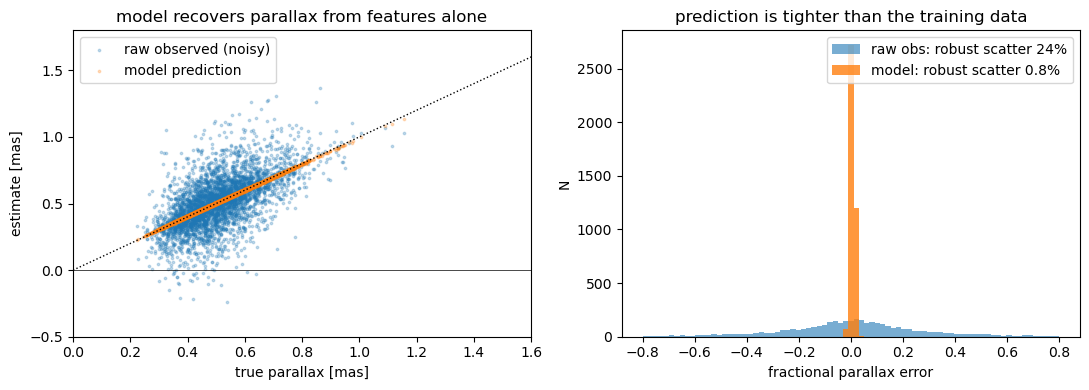

In [5]:
# The payoff: the model's parallax beats the raw measurement it was trained on,
# because the regression pools information across all stars.
plx_sp_toy = np.exp(X @ fit.x)

frac_model = (plx_sp_toy - plx_true) / plx_true
frac_obs   = (plx_obs    - plx_true) / plx_true

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(plx_true, plx_obs,    s=3, alpha=0.25, label="raw observed (noisy)")
ax[0].scatter(plx_true, plx_sp_toy, s=3, alpha=0.25, label="model prediction")
ax[0].plot([0, 2], [0, 2], "k:", lw=1)
ax[0].axhline(0, color="k", lw=0.5)
ax[0].set(xlim=(0, 1.6), ylim=(-0.5, 1.8), xlabel="true parallax [mas]",
          ylabel="estimate [mas]", title="model recovers parallax from features alone")
ax[0].legend()

bins = np.linspace(-0.8, 0.8, 80)
ax[1].hist(frac_obs,   bins=bins, alpha=0.6,
           label=f"raw obs: robust scatter {100*E.robust_scatter(frac_obs):.0f}%")
ax[1].hist(frac_model, bins=bins, alpha=0.8,
           label=f"model: robust scatter {100*E.robust_scatter(frac_model):.1f}%")
ax[1].set(xlabel="fractional parallax error", ylabel="N",
          title="prediction is tighter than the training data")
ax[1].legend()
plt.tight_layout()

## Step 4 — A/B cross-validation: never let a star score itself

The parent sample is split into two halves, **A** and **B** (the `sample` column).
Two models are trained — one on each half — and **every star's `spec_parallax` is
predicted by the model trained on the *other* half**. So all 44,784 published
predictions are out-of-sample.

This is the rule any new model must preserve: *score each fold only with the model
trained on the complementary fold.* Train on A → predict B; train on B → predict A.

In [6]:
for f in ("A", "B"):
    m = cat["sample"] == f
    print(f"fold {f}: {m.sum():>6} stars  ({cat['train'][m].sum()} flagged training_set)")
print(f"\ntraining_set total: {cat['train'].sum()} — the quality-cut subset Paper I fit on")

fold A:  22349 stars  (14159 flagged training_set)
fold B:  22435 stars  (14067 flagged training_set)

training_set total: 28226 — the quality-cut subset Paper I fit on


## Step 5 — The predictions and their uncertainties

The catalog carries the cross-validated outputs: `spec_parallax` and
`spec_parallax_err`. The headline result of the method is **precision**: the
spectrophotometric parallax has a median fractional uncertainty of ~7%, roughly
*independent of distance* — while Gaia's fractional error blows up with distance
for these luminous giants.

median fractional error — spec: 6.8%   Gaia: 20%


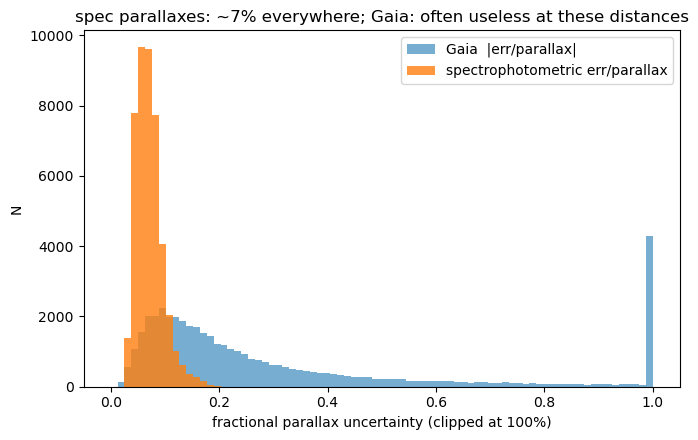

In [7]:
frac_sp = cat["err_sp"] / cat["plx_sp"]                       # spec: always positive
with np.errstate(divide="ignore", invalid="ignore"):
    frac_a = np.abs(cat["err_a"] / cat["plx_a"])              # Gaia: |err/plx|
frac_a = frac_a[np.isfinite(frac_a)]

print(f"median fractional error — spec: {100*np.median(frac_sp):.1f}%   "
      f"Gaia: {100*np.median(frac_a):.0f}%")

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, 1.0, 80)
ax.hist(np.clip(frac_a, 0, 1),  bins=bins, alpha=0.6, label="Gaia  |err/parallax|")
ax.hist(np.clip(frac_sp, 0, 1), bins=bins, alpha=0.8, label="spectrophotometric err/parallax")
ax.set(xlabel="fractional parallax uncertainty (clipped at 100%)", ylabel="N",
       title="spec parallaxes: ~7% everywhere; Gaia: often useless at these distances")
ax.legend()
plt.tight_layout()

## Step 6 — Parallax → distance

Only **now**, with a parallax that is guaranteed positive and ~7% precise, is the
naive inversion safe:

$$d\,[\mathrm{kpc}] = \frac{1}{\varpi^{(\mathrm{sp})}\,[\mathrm{mas}]}$$

For raw Gaia parallaxes this inversion is famously treacherous — undefined for the
negative ones, and severely biased once the fractional error exceeds ~20%
(the noise folds asymmetrically through the reciprocal). That is exactly why:

- the **distance** comes from the spec parallax, but
- all **scoring** (step 7) stays in parallax space and never inverts anything.

median spec distance: 4.73 kpc;  farthest: 65.4 kpc


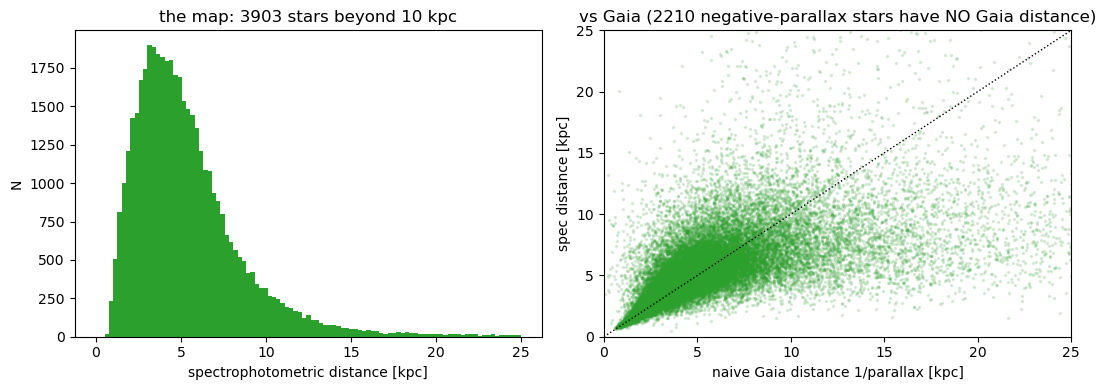

In [8]:
d_sp = 1.0 / cat["plx_sp"]                                    # kpc (plx in mas)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(d_sp, bins=np.linspace(0, 25, 100), color="C2")
ax[0].set(xlabel="spectrophotometric distance [kpc]", ylabel="N",
          title=f"the map: {(d_sp > 10).sum()} stars beyond 10 kpc")

ok = cat["plx_a"] > 0                                         # naive Gaia inversion exists at all
ax[1].scatter(1.0 / cat["plx_a"][ok], d_sp[ok], s=2, alpha=0.15, color="C2")
ax[1].plot([0, 25], [0, 25], "k:", lw=1)
ax[1].set(xlim=(0, 25), ylim=(0, 25), xlabel="naive Gaia distance 1/parallax [kpc]",
          ylabel="spec distance [kpc]",
          title=f"vs Gaia ({(~ok).sum()} negative-parallax stars have NO Gaia distance)")
plt.tight_layout()

print(f"median spec distance: {np.median(d_sp):.2f} kpc;  farthest: {d_sp.max():.1f} kpc")

## Step 7 — Evaluation: the metrics any model must beat

We can't compare against *true* distances (nobody has them), so the trick is a
**high-S/N probe**: the subset where Gaia S/N ≥ 20, i.e. where Gaia itself is good
enough to act as ground truth. Crucially this probe is *evaluation only* — it plays
no role in training and is not a model input.

Three numbers, all computed by `spphot_eval.evaluate`:

- **robust fractional scatter** = $1.48 \times \mathrm{MAD}$ of
  $(\varpi^{(\mathrm{sp})} - \varpi^{(a)})/\varpi^{(a)}$ on the probe — the headline
  precision. Baseline: **9.4%** (paper quotes <9%).
- **bias** = median fractional residual on the probe. Baseline: **−2.7%**.
- **$\chi^2$** of $\chi_n = (\varpi^{(a)} - \varpi^{(\mathrm{sp})})/\sqrt{\sigma_a^2 + \sigma_{sp}^2}$,
  on *all* stars. Honest error bars ⇒ mean $\chi^2 \approx 1$. Baseline:
  mean 2.96 vs median 0.89 — **mean ≫ median means outlier-driven**, exactly as the
  paper reports (dusty/crowded stars the linear model can't capture).

In [9]:
E.print_report(E.evaluate(cat, label="Hogg+18 baseline"))
print()
for f in ("A", "B"):
    E.print_report(E.evaluate(cat, fold=f, label="Hogg+18 baseline"))
    print()

=== Hogg+18 baseline  (fold: all) ===
  N total / hi-S/N probe : 44784 / 1676
  bias  (median frac resid)  : -2.75 %
  SCATTER (robust frac, <9% = beats Paper I) : 9.36 %
  median quoted spec err frac: 6.79 %
  chi2  mean / median / robust : 2.96 / 0.89 / 1.94
    (mean chi2 >> 1 means outlier-driven; honest errors -> ~1)

=== Hogg+18 baseline  (fold: A) ===
  N total / hi-S/N probe : 22349 / 828
  bias  (median frac resid)  : -2.75 %
  SCATTER (robust frac, <9% = beats Paper I) : 9.39 %
  median quoted spec err frac: 6.89 %
  chi2  mean / median / robust : 3.62 / 0.89 / 1.94
    (mean chi2 >> 1 means outlier-driven; honest errors -> ~1)

=== Hogg+18 baseline  (fold: B) ===
  N total / hi-S/N probe : 22435 / 848
  bias  (median frac resid)  : -2.75 %
  SCATTER (robust frac, <9% = beats Paper I) : 9.33 %
  median quoted spec err frac: 6.70 %
  chi2  mean / median / robust : 2.30 / 0.89 / 1.96
    (mean chi2 >> 1 means outlier-driven; honest errors -> ~1)



## Step 8 — Diagnostic figures

`spphot_plots` renders the same diagnostics for the baseline and for any new model:

- **Fig. 2** (left: training set; right: hi-S/N probe colored by Gaia S/N) — the
  predicted vs measured parallax should hug the 1:1 line on the probe.
- **Residual histogram** — the fractional-residual core whose width is the robust scatter.

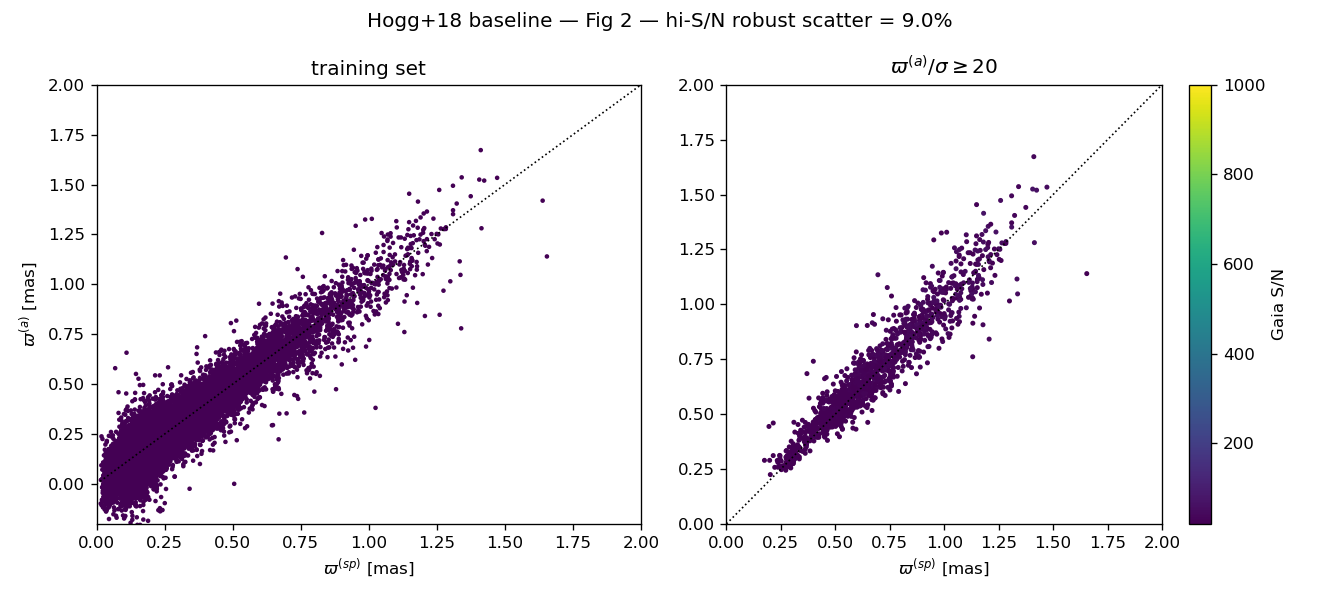

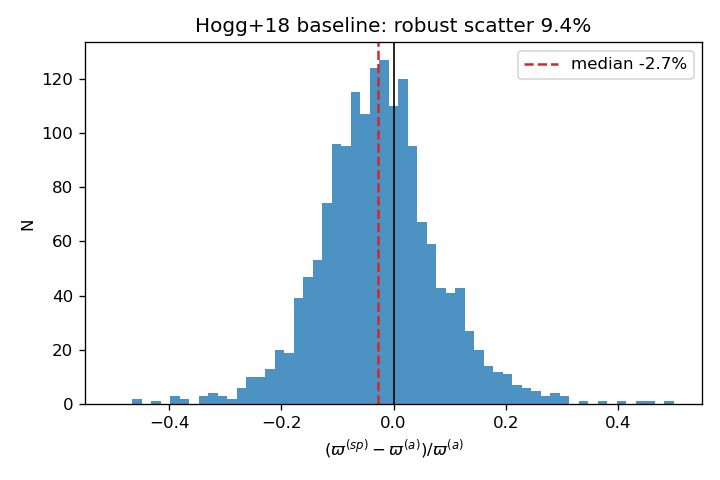

In [10]:
from IPython.display import Image, display

display(Image(P.fig2(cat, "nb_fig2.png", title="Hogg+18 baseline — Fig 2")))
display(Image(P.residual_hist(cat, "nb_resid_hist.png", title="Hogg+18 baseline")))

## Step 9 — Scoring your own model (the whole point of this harness)

Your model (e.g. a heteroscedastic NN) writes a FITS file with the same four
parallax columns — copy the Gaia columns through unchanged, fill
`spec_parallax(_err)` with predictions **on the fold it did not train on** — then:

```python
import spphot_eval as E, spphot_plots as P

base = E.load_catalog("hogg2018.fits")
new  = E.load_catalog("my_nn_foldB.fits")

E.print_report(E.evaluate(new, fold="B", label="NN"))
P.compare_scatter(base, new, "compare.png")   # overlaid residual histograms
```

**"Beating the baseline" means all three of:**

1. robust scatter **< 9.4%** (a tighter core);
2. **mean $\chi^2$ closer to 1** — the real win: an aleatoric $\sigma_{\rm int}$ head
   should absorb the dusty/crowded outliers that inflate the baseline's mean $\chi^2$ to ~3;
3. A/B fold independence preserved — never leak.

Note `evaluate(..., offset=...)` exists to apply a Gaia DR2 parallax zero-point
offset if you choose to model one; the baseline numbers above use `offset=0`.